# Telco Customer Churn — Exploratory Data Analysis

**Group project brief — questions this notebook builds toward:**

1. Demographics of churners — gender, age, family makeup, products held, and *why* they churn
2. What factors most influence someone churning
3. What sign-up factor should we incentivise

This notebook is the **shared EDA foundation** for the group. It does *not* build the predictive model
(that lives in the modeling notebook) — its job is to understand the data, flag quality/leakage issues,
and produce the descriptive analysis that feeds the presentation deck.

**Data:** IBM Telco Customer Churn dataset, 7,043 customers, 31 columns.

> Place `1__Project_Data.xlsx` in the same folder as this notebook before running.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 140)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

CHURN_COLOR = {'No': '#4C72B0', 'Yes': '#C44E52'}


## 1. Load & Overview

In [2]:
DATA_PATH = "1__Project_Data.xlsx"
df_raw = pd.read_excel(DATA_PATH)
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()


Shape: 7,043 rows x 31 columns


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,Competitor had better devices


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [4]:
# Missing values and duplicates
missing = df_raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing if len(missing) else "  (none detected by pandas isna — see Total Charges check below)")
print()
print(f"Fully duplicated rows: {df_raw.duplicated().sum()}")
print(f"Duplicated CustomerIDs: {df_raw['CustomerID'].duplicated().sum()}")


Columns with missing values:
Churn Reason    5174
dtype: int64

Fully duplicated rows: 0
Duplicated CustomerIDs: 0


In [5]:
# Cardinality scan — flags columns that are IDs, near-constant, or high-cardinality
card = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'n_unique': df_raw.nunique(),
    'pct_unique': (df_raw.nunique() / len(df_raw) * 100).round(1)
}).sort_values('n_unique', ascending=False)
card


,dtype,n_unique,pct_unique
CustomerID,str,7043,100.0
Total Charges,object,6531,92.7
Zip Code,int64,1652,23.5
Latitude,float64,1652,23.5
Lat Long,str,1652,23.5
Longitude,float64,1651,23.4
Monthly Charges,float64,1585,22.5
City,str,1129,16.0
Tenure Months,int64,73,1.0
Churn Reason,str,20,0.3


**Notes from the scan above:**
- `CustomerID` is a unique identifier — no analytical value, drop before modeling.
- `Count` is constant (always 1) — an artifact of the source export, drop.
- `Country`, `State` are constant (this extract is US/California only) — check below.
- `City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude` are high-cardinality geographic fields.
  Useful for a map visual, but a **memorization risk** for tree-based models if used raw.


## 2. Data Quality Fixes

Two issues need fixing before any numeric analysis or modeling.

In [7]:
# Issue 1: Total Charges is stored as text, with blank strings instead of 0
blank_mask = df_raw['Total Charges'].astype(str).str.strip() == ''
print(f"Blank 'Total Charges' rows: {blank_mask.sum()}")
df_raw.loc[blank_mask, ['CustomerID', 'Tenure Months', 'Monthly Charges', 'Total Charges']]


Blank 'Total Charges' rows: 11


,CustomerID,Tenure Months,Monthly Charges,Total Charges
2234,4472-LVYGI,0,52.55,
2438,3115-CZMZD,0,20.25,
2568,5709-LVOEQ,0,80.85,
2667,4367-NUYAO,0,25.75,
2856,1371-DWPAZ,0,56.05,
4331,7644-OMVMY,0,19.85,
4687,3213-VVOLG,0,25.35,
5104,2520-SGTTA,0,20.00,
5719,2923-ARZLG,0,19.70,
6772,4075-WKNIU,0,73.35,


In [8]:
# Every blank belongs to a brand-new customer (Tenure Months == 0), so Total Charges = 0 is correct,
# not a true missing value.
print("Tenure Months for blank rows:", df_raw.loc[blank_mask, 'Tenure Months'].unique())

df = df_raw.copy()
df['Total Charges'] = pd.to_numeric(df['Total Charges'].astype(str).str.strip(), errors='coerce').fillna(0)
print("Total Charges dtype now:", df['Total Charges'].dtype)


Tenure Months for blank rows: [0]
Total Charges dtype now: float64


In [9]:
# Issue 2: Churn Reason is only populated for churned customers — confirm this lines up with Churn Value
print(df.groupby('Churn Value')['Churn Reason'].apply(lambda s: s.notna().sum()))
print()
n_active = (df['Churn Value'] == 0).sum()
n_churned = (df['Churn Value'] == 1).sum()
print(f"Active (non-churned) customers: {n_active:,}  <- this is the deployment pool for targeting")
print(f"Churned customers:              {n_churned:,}")


Churn Value
0       0
1    1869
Name: Churn Reason, dtype: int64



Active (non-churned) customers: 5,174  <- this is the deployment pool for targeting
Churned customers:              1,869


**This confirms the deployment framing used across the project:** `Churn Reason` is null for every
active customer and populated for every churned one — it is a **near-perfect leakage proxy for the
target** and must be excluded from any predictive model, kept only for this descriptive analysis.
It also confirms the correct base for "top 500 most likely to churn" is the **active pool
(n = 5,174)**, not the full dataset of 7,043.


In [10]:
# Columns to exclude from modeling (leakage / identifiers / redundant target) — for hand-off to the
# modeling notebook. Kept in `df` here since this notebook is descriptive.
LEAKAGE_OR_ID_COLS = ['CustomerID', 'Count', 'Churn Label', 'Churn Reason']
print("Flagged as modeling-exclusions (leakage/ID/redundant):", LEAKAGE_OR_ID_COLS)
print("Churn Label vs Churn Value agreement check:",
      (df['Churn Label'].map({'Yes': 1, 'No': 0}) == df['Churn Value']).all())


Flagged as modeling-exclusions (leakage/ID/redundant): ['CustomerID', 'Count', 'Churn Label', 'Churn Reason']
Churn Label vs Churn Value agreement check: True


## 3. Target Variable — Churn Rate

Overall churn rate: 26.5%  (1,869 of 7,043 customers)


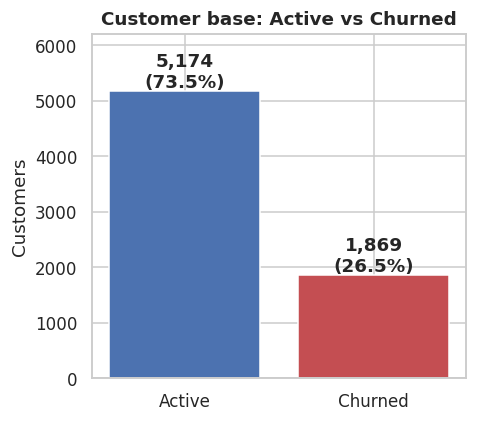

In [11]:
churn_rate = df['Churn Value'].mean()
print(f"Overall churn rate: {churn_rate:.1%}  ({n_churned:,} of {len(df):,} customers)")

fig, ax = plt.subplots(figsize=(4.5, 4))
counts = df['Churn Value'].value_counts().sort_index()
bars = ax.bar(['Active', 'Churned'], counts.values, color=[CHURN_COLOR['No'], CHURN_COLOR['Yes']])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v + 60, f"{v:,}\n({v/len(df):.1%})", ha='center', fontweight='bold')
ax.set_title('Customer base: Active vs Churned')
ax.set_ylabel('Customers')
ax.set_ylim(0, counts.max()*1.2)
plt.tight_layout()
plt.show()


~26.5% churn is a meaningful class imbalance to keep in mind — it's why the modeling workstream
evaluates on ranking metrics (precision@K, ROC AUC) rather than accuracy, and why calibration was
checked before trusting predicted probabilities for stakeholder reporting.

## 4. Demographics of Churners
*Gender, age (Senior Citizen), and family makeup (Partner / Dependents)*


In [12]:
demo_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents']

def churn_rate_table(data, col, target='Churn Value'):
    t = data.groupby(col)[target].agg(['mean', 'count']).rename(columns={'mean': 'churn_rate', 'count': 'n'})
    t['churn_rate'] = t['churn_rate'].round(3)
    return t.sort_values('churn_rate', ascending=False)

for c in demo_cols:
    print(f"--- {c} ---")
    print(churn_rate_table(df, c))
    print()


--- Gender ---
        churn_rate     n
Gender                  
Female       0.269  3488
Male         0.262  3555

--- Senior Citizen ---
                churn_rate     n
Senior Citizen                  
Yes                  0.417  1142
No                   0.236  5901

--- Partner ---
         churn_rate     n
Partner                  
No            0.330  3641
Yes           0.197  3402

--- Dependents ---
            churn_rate     n
Dependents                  
No               0.326  5416
Yes              0.065  1627



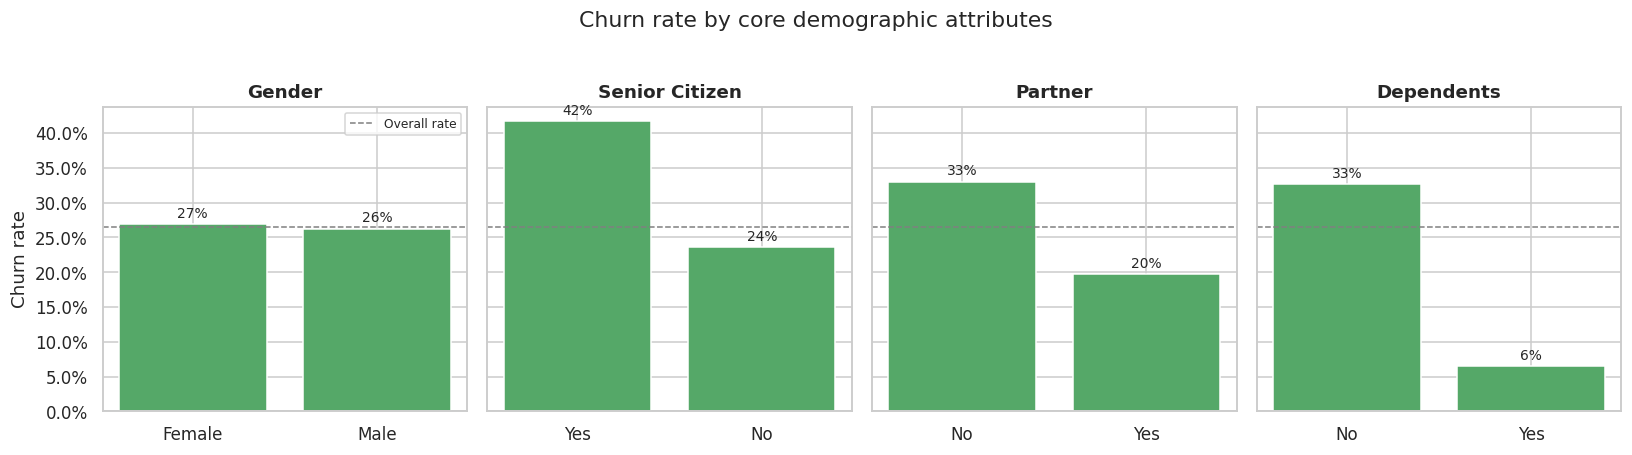

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
for ax, c in zip(axes, demo_cols):
    t = churn_rate_table(df, c)
    bars = ax.bar(t.index.astype(str), t['churn_rate'], color='#55A868')
    ax.axhline(churn_rate, color='gray', linestyle='--', linewidth=1, label='Overall rate')
    ax.set_title(c)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.tick_params(axis='x', rotation=0)
    for b, v in zip(bars, t['churn_rate']):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.0%}", ha='center', fontsize=9)
axes[0].set_ylabel('Churn rate')
axes[0].legend(fontsize=8)
plt.suptitle('Churn rate by core demographic attributes', y=1.03)
plt.tight_layout()
plt.show()


**Reading these:** Gender shows essentially no relationship with churn — not a useful targeting or
messaging lever. Senior Citizen, Partner, and Dependents each show a real split — customers who are
older, single, and without dependents churn more. This points toward a "family makeup" story rather
than a "type of person" story: churners skew toward customers with fewer household ties.


                      churn_rate     n
Family Type                           
Neither                    0.344  3339
Partner only               0.295  2077
Dependents only            0.166   302
Partner & Dependents       0.042  1325


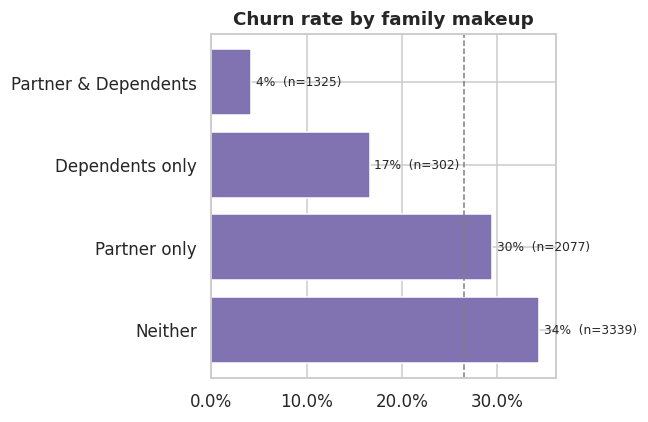

In [14]:
# Combine Partner x Dependents into a single "family type" segment for the deck
df['Family Type'] = np.select(
    [
        (df['Partner'] == 'Yes') & (df['Dependents'] == 'Yes'),
        (df['Partner'] == 'Yes') & (df['Dependents'] == 'No'),
        (df['Partner'] == 'No')  & (df['Dependents'] == 'Yes'),
        (df['Partner'] == 'No')  & (df['Dependents'] == 'No'),
    ],
    ['Partner & Dependents', 'Partner only', 'Dependents only', 'Neither'],
    default='Unknown',
)
fam = churn_rate_table(df, 'Family Type')
print(fam)

fig, ax = plt.subplots(figsize=(6, 4))
fam_sorted = fam.sort_values('churn_rate', ascending=False)
bars = ax.barh(fam_sorted.index, fam_sorted['churn_rate'], color='#8172B2')
ax.axvline(churn_rate, color='gray', linestyle='--', linewidth=1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Churn rate by family makeup')
for b, (rate, n) in zip(bars, zip(fam_sorted['churn_rate'], fam_sorted['n'])):
    ax.text(rate+0.005, b.get_y()+b.get_height()/2, f"{rate:.0%}  (n={int(n)})", va='center', fontsize=8)
plt.tight_layout()
plt.show()


In [15]:
# Senior citizens living alone (no partner, no dependents) — a compounded-risk segment worth
# calling out explicitly in the deck
seg = df.groupby(['Senior Citizen', 'Family Type'])['Churn Value'].agg(['mean','count'])
seg.columns = ['churn_rate', 'n']
seg['churn_rate'] = seg['churn_rate'].round(3)
seg.sort_values('churn_rate', ascending=False)


churn_rate     n
Senior Citizen Family Type                           
Yes            Neither                    0.489   558
               Dependents only            0.455    11
               Partner only               0.374   511
No             Neither                    0.315  2781
               Partner only               0.269  1566
               Dependents only            0.155   291
Yes            Partner & Dependents       0.113    62
No             Partner & Dependents       0.039  1263

## 5. Tenure & Charges — Who's Newer, Who's Paying More

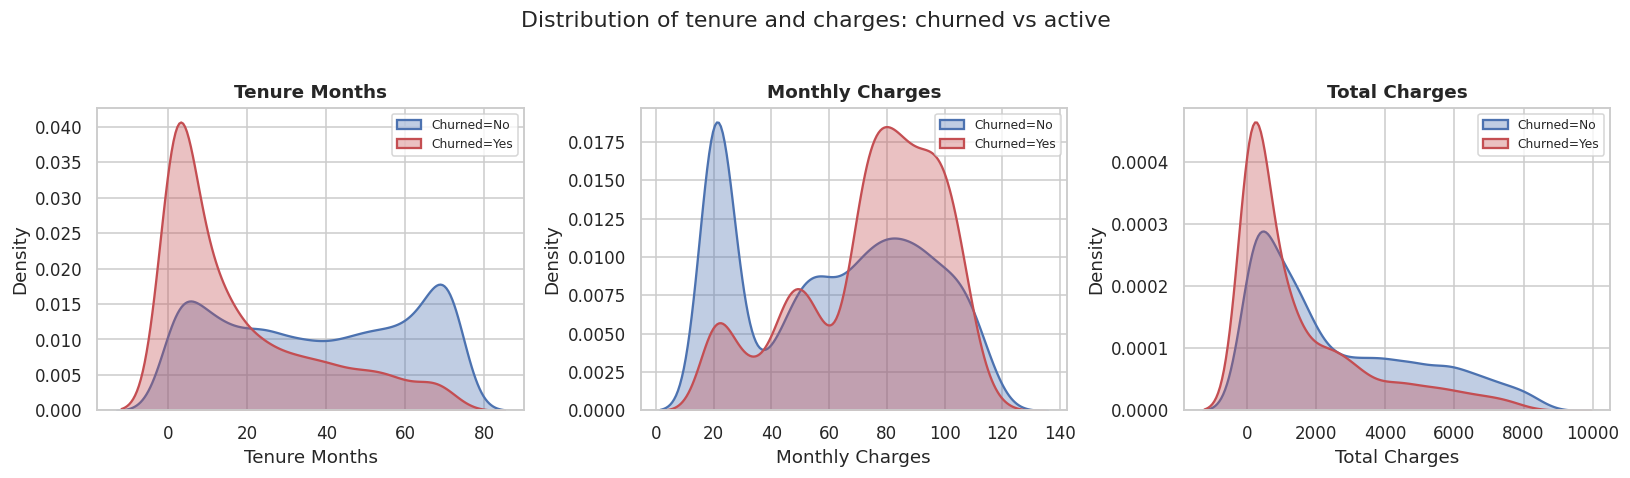

Tenure Months       Monthly Charges       Total Charges        
                   median  mean          median  mean        median    mean
Churn Label                                                                
No                   38.0  37.6            64.4  61.3        1679.5  2549.9
Yes                  10.0  18.0            79.6  74.4         703.6  1531.8

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col in zip(axes, ['Tenure Months', 'Monthly Charges', 'Total Charges']):
    for label, color in CHURN_COLOR.items():
        val = 'Yes' if label == 'Yes' else 'No'
        subset = df[df['Churn Label'] == val][col]
        sns.kdeplot(subset, ax=ax, label=f"Churned={val}", color=color, fill=True, alpha=0.35, linewidth=1.5)
    ax.set_title(col)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Density')
plt.suptitle('Distribution of tenure and charges: churned vs active', y=1.03)
plt.tight_layout()
plt.show()

df.groupby('Churn Label')[['Tenure Months', 'Monthly Charges', 'Total Charges']].agg(['median', 'mean']).round(1)


**Reading this:** Churners are heavily concentrated in low tenure (many churn within the first
few months) and pay somewhat *higher* monthly charges on average — the classic "expensive, unproven
new customer" churn profile. Total Charges is lower for churners mainly because it's a function of
tenure (they haven't been billed long), not because they're lower-value customers per month.


               churn_rate     n
Tenure Bucket                  
0-6 mo              0.529  1481
7-12 mo             0.359   705
13-24 mo            0.287  1024
25-48 mo            0.204  1594
49-72 mo            0.095  2239


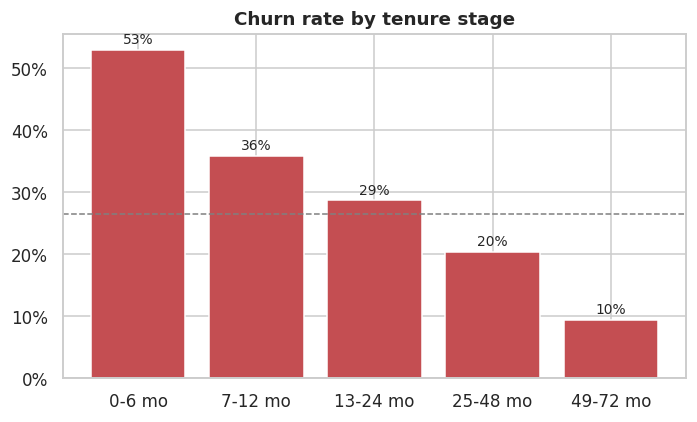

In [17]:
# Tenure bucketed into "customer lifecycle" stages — useful framing for the deck and directly
# relevant to the sign-up-incentive question
bins = [-1, 6, 12, 24, 48, 72]
labels = ['0-6 mo', '7-12 mo', '13-24 mo', '25-48 mo', '49-72 mo']
df['Tenure Bucket'] = pd.cut(df['Tenure Months'], bins=bins, labels=labels)

tb = churn_rate_table(df, 'Tenure Bucket')
print(tb)

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(tb.index.astype(str), tb['churn_rate'], color='#C44E52')
ax.axhline(churn_rate, color='gray', linestyle='--', linewidth=1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Churn rate by tenure stage')
for b, v in zip(bars, tb['churn_rate']):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.0%}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()


Churn risk is front-loaded: customers in their first 6 months churn at roughly double-plus the
overall rate, then risk falls off sharply. This is a strong argument for an **early-tenure retention
touchpoint** rather than spreading retention spend evenly across the base.


## 6. Products & Services Held by Churners
*What do churners have signed up for?*


In [18]:
service_cols = ['Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security',
                'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

rows = []
for c in service_cols:
    t = churn_rate_table(df, c)
    for idx, r in t.iterrows():
        rows.append({'Service': c, 'Category': idx, 'Churn Rate': r['churn_rate'], 'n': r['n']})
service_summary = pd.DataFrame(rows)
service_summary


,Service,Category,Churn Rate,n
0,Phone Service,Yes,0.267,6361.0
1,Phone Service,No,0.249,682.0
2,Multiple Lines,Yes,0.286,2971.0
3,Multiple Lines,No,0.250,3390.0
4,Multiple Lines,No phone service,0.249,682.0
5,Internet Service,Fiber optic,0.419,3096.0
6,Internet Service,DSL,0.190,2421.0
7,Internet Service,No,0.074,1526.0
8,Online Security,No,0.418,3498.0
9,Online Security,Yes,0.146,2019.0


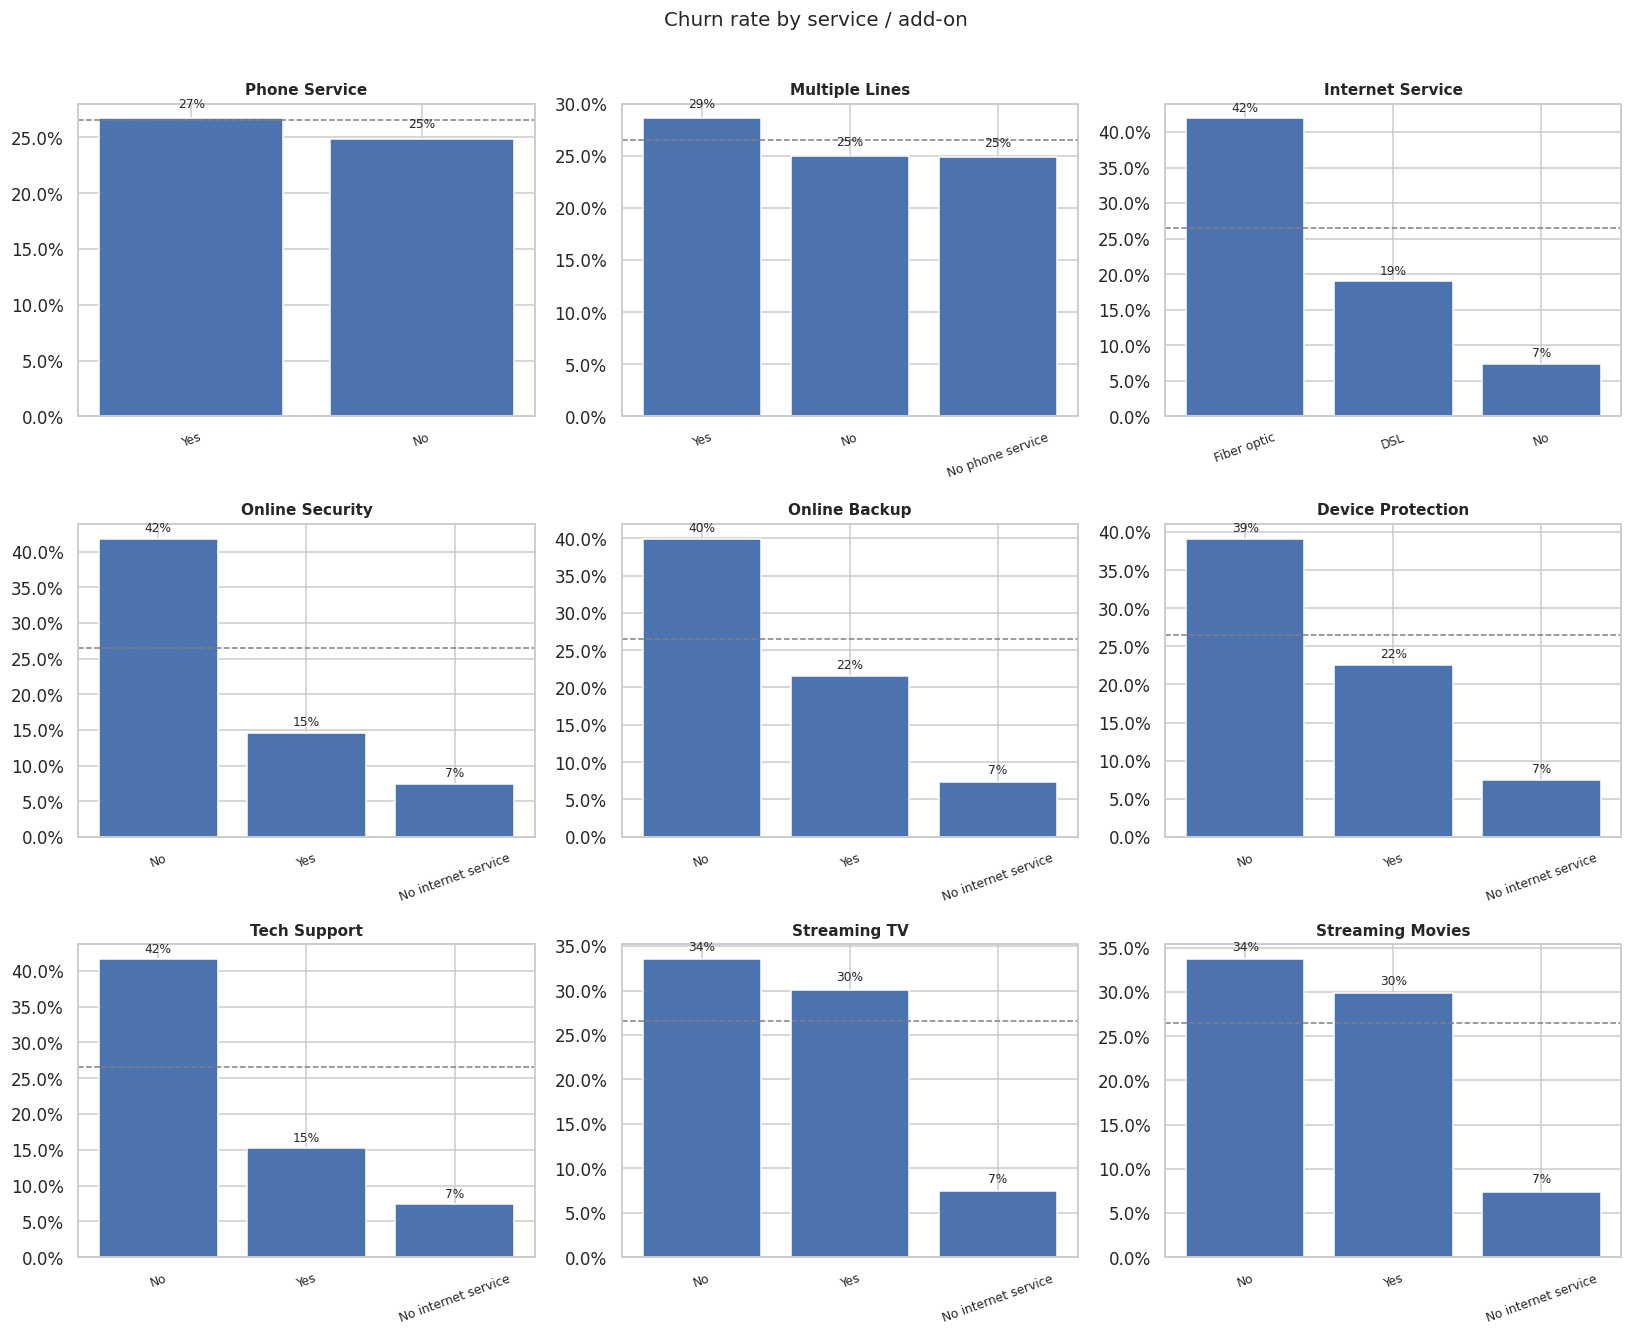

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, c in zip(axes.flat, service_cols):
    t = churn_rate_table(df, c)
    bars = ax.bar(t.index.astype(str), t['churn_rate'], color='#4C72B0')
    ax.axhline(churn_rate, color='gray', linestyle='--', linewidth=1)
    ax.set_title(c, fontsize=10)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    for b, v in zip(bars, t['churn_rate']):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.0%}", ha='center', fontsize=8)
plt.suptitle('Churn rate by service / add-on', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


**Reading this:** Internet Service type stands out sharply — **Fiber optic** customers churn far
more than DSL or no-internet customers, despite (or perhaps because of) being the premium product.
Across the add-on services (Online Security, Backup, Device Protection, Tech Support), a consistent
pattern holds: customers **without** the add-on churn substantially more than those with it. Streaming
TV/Movies show almost no relationship — these look like lifestyle add-ons rather than retention levers.
Phone Service and Multiple Lines show weak relationships.

This suggests two different product stories: Fiber optic may have service-quality or price issues
worth investigating qualitatively, while the security/support add-ons look like genuine retention
tools (bundling them in retains customers) — though causality could run either way (engaged customers
buy more add-ons *and* stay longer).


             churn_rate     n
Addon Count                  
1                 0.458   966
2                 0.358  1033
3                 0.274  1118
4                 0.223   852
0                 0.214  2219
5                 0.124   571
6                 0.053   284


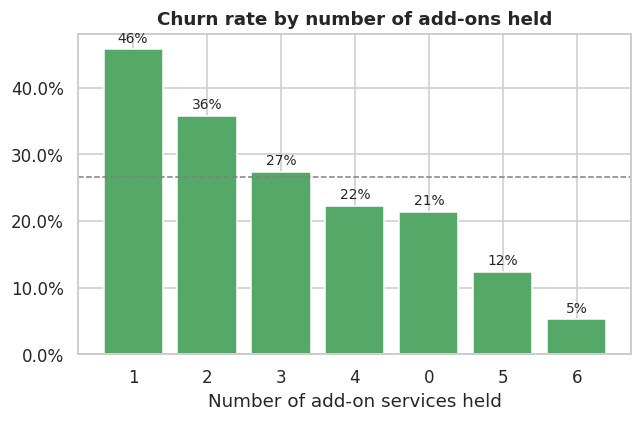

In [20]:
# How many services does each customer have? A simple "service depth" signal
addon_cols = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
              'Streaming TV', 'Streaming Movies']
df['Addon Count'] = (df[addon_cols] == 'Yes').sum(axis=1)

addon_churn = churn_rate_table(df, 'Addon Count')
print(addon_churn)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(addon_churn.index.astype(str), addon_churn['churn_rate'], color='#55A868')
ax.axhline(churn_rate, color='gray', linestyle='--', linewidth=1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('Number of add-on services held')
ax.set_title('Churn rate by number of add-ons held')
for b, v in zip(bars, addon_churn['churn_rate']):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.0%}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()


A clean, monotonic relationship: the more add-on services a customer holds, the less likely they are to churn. This is one of the strongest and most actionable patterns in the dataset.

## 7. Why Are They Churning — Stated Reasons
*Descriptive only — among churned customers. `Churn Reason` is excluded from any predictive model.*


In [21]:
reason_counts = df['Churn Reason'].value_counts()
print(f"{reason_counts.sum():,} churned customers gave a reason (of {n_churned:,} total)")
reason_counts


1,869 churned customers gave a reason (of 1,869 total)


Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Limited range of services                     44
Lack of affordable download/upload speed      44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

In [22]:
# Group raw reasons into broader themes for a cleaner deck chart
theme_map = {
    'Competitor had better devices': 'Competitor',
    'Competitor made better offer': 'Competitor',
    'Competitor offered higher download speeds': 'Competitor',
    'Competitor offered more data': 'Competitor',
    'Attitude of support person': 'Service/Attitude',
    'Attitude of service provider': 'Service/Attitude',
    'Poor expertise of phone support': 'Service/Attitude',
    'Poor expertise of online support': 'Service/Attitude',
    'Service dissatisfaction': 'Service/Attitude',
    'Product dissatisfaction': 'Product',
    'Network reliability': 'Product',
    'Limited range of services': 'Product',
    'Lack of self-service on Website': 'Product',
    'Price too high': 'Price',
    'Extra data charges': 'Price',
    'Long distance charges': 'Price',
    'Lack of affordable download/upload speed': 'Price',
    'Moved': 'Other/Life event',
    'Deceased': 'Other/Life event',
    "Don't know": 'Other/Life event',
}
df['Churn Theme'] = df['Churn Reason'].map(theme_map)
theme_counts = df['Churn Theme'].value_counts()
print(theme_counts)
print()
print((theme_counts / theme_counts.sum() * 100).round(1).astype(str) + '%')


Churn Theme
Competitor          621
Service/Attitude    455
Product             337
Price               243
Other/Life event    213
Name: count, dtype: int64

Churn Theme
Competitor          33.2%
Service/Attitude    24.3%
Product             18.0%
Price               13.0%
Other/Life event    11.4%
Name: count, dtype: str


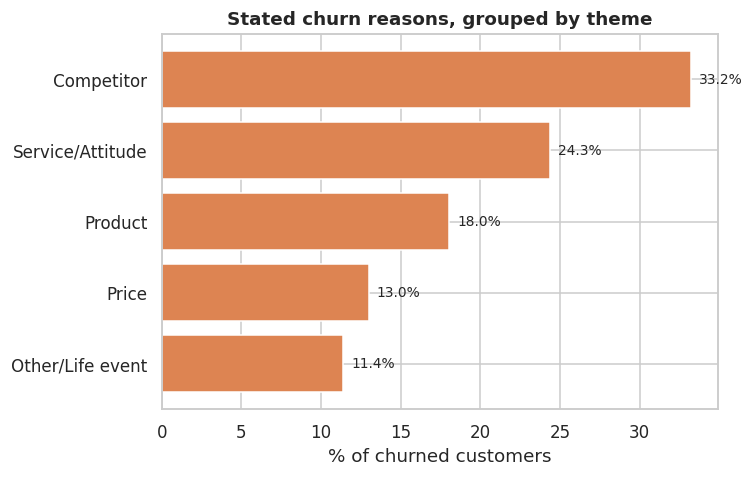

In [23]:
fig, ax = plt.subplots(figsize=(7, 4.5))
theme_pct = (theme_counts / theme_counts.sum() * 100).sort_values()
bars = ax.barh(theme_pct.index, theme_pct.values, color='#DD8452')
ax.set_title('Stated churn reasons, grouped by theme')
ax.set_xlabel('% of churned customers')
for b, v in zip(bars, theme_pct.values):
    ax.text(v+0.5, b.get_y()+b.get_height()/2, f"{v:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()


**Reading this:** Competitive pressure (better offers, devices, speeds, data) is the single
largest stated driver — this is a market/pricing story more than a service-failure story. Service and
attitude issues (support quality, dissatisfaction) form the second-largest bucket and are the most
directly *fixable* internally. Price complaints are a smaller but concrete third theme. Life-event
churn (moved, deceased, "don't know") is largely unavoidable and shouldn't be a retention-spend target.


## 8. Sign-Up / Account Factors
*What should be incentivised at sign-up? Contract, billing, and payment method.*


In [24]:
signup_cols = ['Contract', 'Paperless Billing', 'Payment Method']
for c in signup_cols:
    print(f"--- {c} ---")
    print(churn_rate_table(df, c))
    print()


--- Contract ---
                churn_rate     n
Contract                        
Month-to-month       0.427  3875
One year             0.113  1473
Two year             0.028  1695

--- Paperless Billing ---
                   churn_rate     n
Paperless Billing                  
Yes                     0.336  4171
No                      0.163  2872

--- Payment Method ---
                           churn_rate     n
Payment Method                             
Electronic check                0.453  2365
Mailed check                    0.191  1612
Bank transfer (automatic)       0.167  1544
Credit card (automatic)         0.152  1522



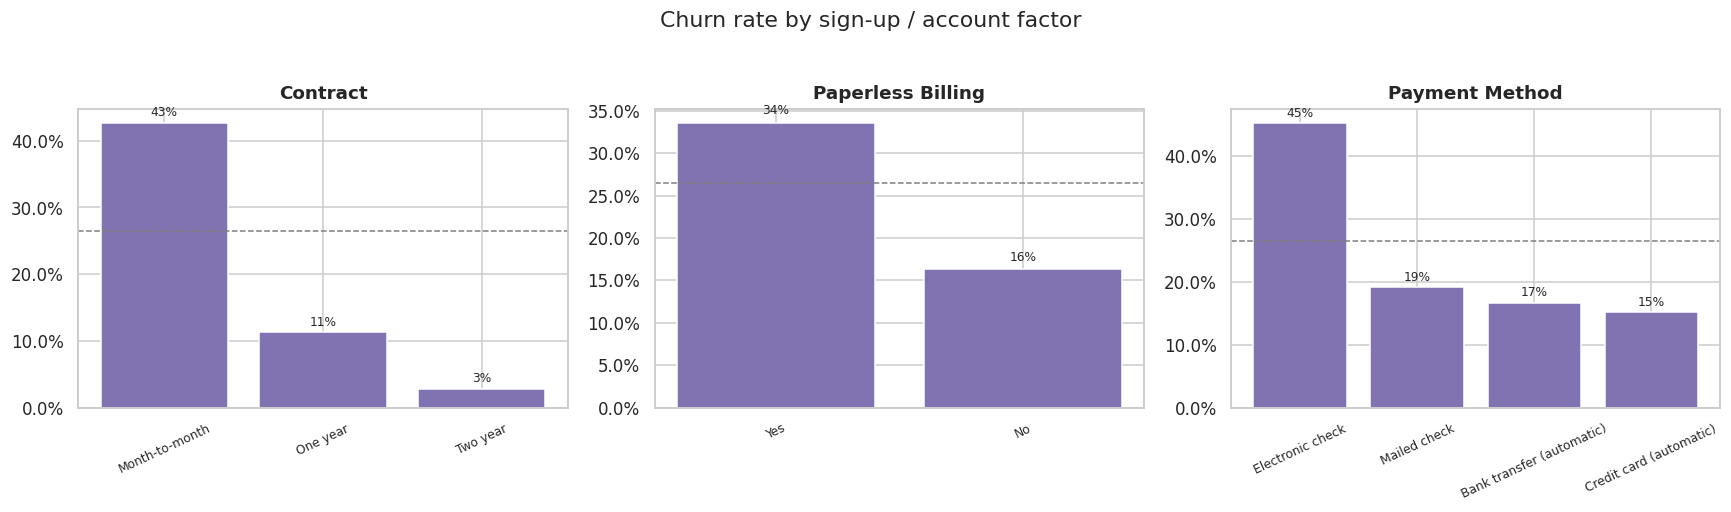

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, c in zip(axes, signup_cols):
    t = churn_rate_table(df, c).sort_values('churn_rate', ascending=False)
    bars = ax.bar(t.index.astype(str), t['churn_rate'], color='#8172B2')
    ax.axhline(churn_rate, color='gray', linestyle='--', linewidth=1)
    ax.set_title(c)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.tick_params(axis='x', rotation=25, labelsize=8)
    for b, v in zip(bars, t['churn_rate']):
        ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.0%}", ha='center', fontsize=8)
plt.suptitle('Churn rate by sign-up / account factor', y=1.03)
plt.tight_layout()
plt.show()


**Contract type is the single strongest lever in this whole dataset.** Month-to-month customers
churn at a dramatically higher rate than one-year or two-year contract holders. Paperless billing and
electronic-check payment are both associated with notably higher churn too, likely correlated with the
same "less committed / more price-sensitive" customer segment that picks month-to-month plans.


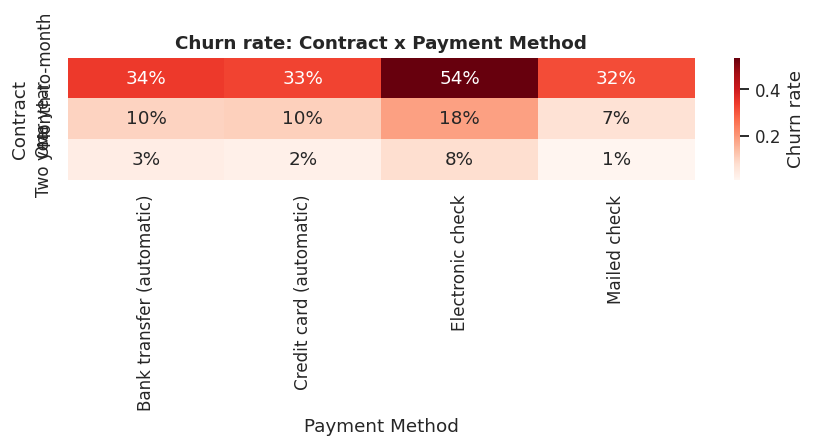

Payment Method,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,0.341,0.328,0.537,0.316
One year,0.097,0.103,0.184,0.068
Two year,0.034,0.022,0.077,0.008


In [26]:
# Contract x Payment Method interaction — where do the highest-risk combinations sit?
pivot = df.pivot_table(index='Contract', columns='Payment Method', values='Churn Value', aggfunc='mean')
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='Reds', ax=ax, cbar_kws={'label': 'Churn rate'})
ax.set_title('Churn rate: Contract x Payment Method')
plt.tight_layout()
plt.show()
pivot.round(3)


Month-to-month + electronic check is the single riskiest combination by a wide margin. This is a
concrete, actionable sign-up recommendation: **incentivise longer contract terms and/or automatic
payment methods (bank transfer / credit card) at the point of sign-up** — ideally targeted at
new, month-to-month, electronic-check customers, since that's where risk concentrates.


## 9. What Factors Most Influence Churn — Ranking All Features

In [27]:
# Cramer's V for categorical features (association strength, 0-1, comparable across features
# regardless of number of categories)
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

categorical_features = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
                         'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup',
                         'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
                         'Contract', 'Paperless Billing', 'Payment Method']

assoc = []
for c in categorical_features:
    v = cramers_v(df[c], df['Churn Value'])
    assoc.append({'Feature': c, 'Type': 'categorical', 'Association (Cramer V)': round(v, 3)})

# Point-biserial correlation for numeric features (equivalent to Pearson r vs a 0/1 target)
numeric_features = ['Tenure Months', 'Monthly Charges', 'Total Charges']
for c in numeric_features:
    r, _ = pointbiserialr(df['Churn Value'], df[c])
    assoc.append({'Feature': c, 'Type': 'numeric', 'Association (Cramer V)': round(abs(r), 3)})

assoc_df = pd.DataFrame(assoc).rename(columns={'Association (Cramer V)': 'Association strength'})
assoc_df = assoc_df.sort_values('Association strength', ascending=False).reset_index(drop=True)
assoc_df


,Feature,Type,Association strength
0,Contract,categorical,0.410
1,Tenure Months,numeric,0.352
2,Online Security,categorical,0.347
3,Tech Support,categorical,0.343
4,Internet Service,categorical,0.322
5,Payment Method,categorical,0.303
6,Online Backup,categorical,0.292
7,Device Protection,categorical,0.282
8,Dependents,categorical,0.248
9,Streaming Movies,categorical,0.231


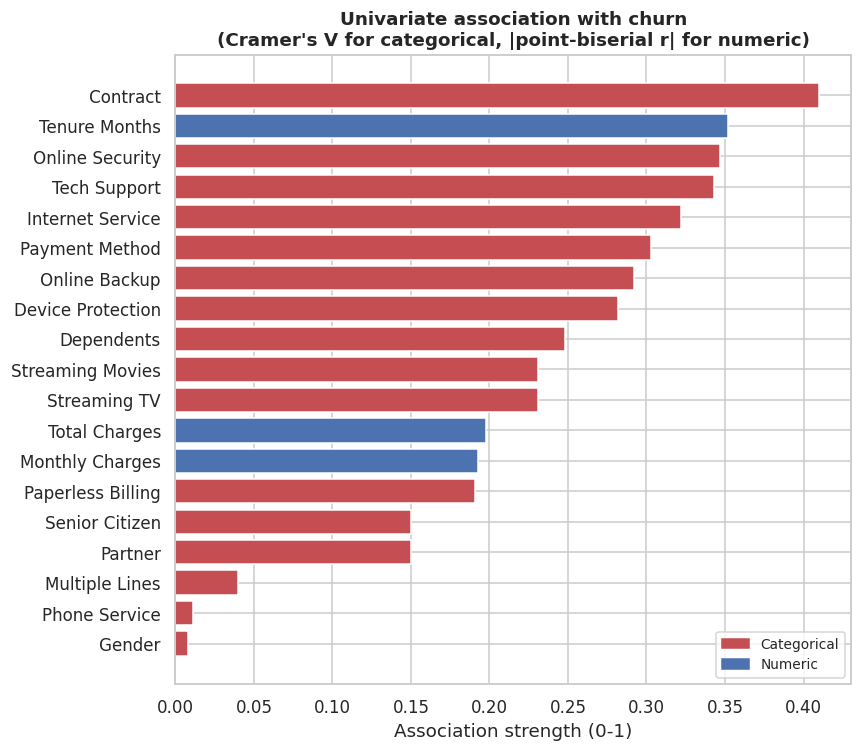

In [28]:
fig, ax = plt.subplots(figsize=(8, 7))
plot_df = assoc_df.sort_values('Association strength')
colors = ['#C44E52' if t == 'categorical' else '#4C72B0' for t in plot_df['Type']]
bars = ax.barh(plot_df['Feature'], plot_df['Association strength'], color=colors)
ax.set_title("Univariate association with churn\n(Cramer's V for categorical, |point-biserial r| for numeric)")
ax.set_xlabel('Association strength (0-1)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#C44E52', label='Categorical'), Patch(color='#4C72B0', label='Numeric')],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


**Top factors by univariate association:** `Contract` and `Tenure Months` dominate — both really
measure the same underlying idea (customer commitment / relationship length). `Internet Service`
(fiber optic risk), `Payment Method`, `Online Security`, and `Tech Support` form a clear second tier.
Demographic factors (Gender, Partner, Dependents, Senior Citizen) sit lower — they matter, but far
less than contractual and service-usage factors.

**Important caveat for the deck:** these are *univariate* associations — they don't control for
overlap between features (e.g. month-to-month customers are also disproportionately new and
disproportionately fiber). The modeling workstream's permutation-importance / SHAP analysis on the
fitted HistGradientBoostingClassifier is the right place to see which factors matter *independently*,
controlling for the others. Treat this ranking as "where to point the deck's story," not as a final
causal answer.


## 10. Geographic Snapshot (California)

In [29]:
geo = churn_rate_table(df, 'State') if df['State'].nunique() > 1 else None
top_states = df.groupby('City')['Churn Value'].agg(['mean', 'count'])
top_states.columns = ['churn_rate', 'n']
top_states = top_states[top_states['n'] >= 20].sort_values('churn_rate', ascending=False)
print(f"Cities with n>=20 customers: {len(top_states)}")
print("\nHighest-churn cities (n>=20):")
print(top_states.head(10))
print("\nLowest-churn cities (n>=20):")
print(top_states.tail(10))


Cities with n>=20 customers: 35

Highest-churn cities (n>=20):
                 churn_rate    n
City                            
Santa Rosa         0.458333   24
North Hollywood    0.450000   20
Modesto            0.428571   28
Santa Barbara      0.357143   28
San Diego          0.333333  150
Glendale           0.325000   40
Torrance           0.320000   25
Pasadena           0.300000   30
San Francisco      0.298077  104
Los Angeles        0.295082  305

Lowest-churn cities (n>=20):
              churn_rate   n
City                        
Chula Vista     0.200000  25
Inglewood       0.200000  25
Van Nuys        0.200000  20
Santa Monica    0.200000  25
Salinas         0.200000  20
Irvine          0.178571  28
Whittier        0.166667  30
Orange          0.150000  20
Corona          0.100000  20
Bakersfield     0.075000  40


All customers in this extract are from California, so geography is a within-state city/zip
story rather than a national one. There's real city-to-city spread, but with 1,000+ distinct cities
and zip codes, this is a **high-cardinality field**: fine for a map visual in the deck, but it should
be aggregated (e.g. by region) or dropped rather than used raw as a model feature, per the leakage
notes in Section 2.


## 11. Summary — Key Findings for the Deck

**Demographics of churners:**
- Gender has no meaningful relationship with churn.
- Churners skew slightly older (Senior Citizens churn more) and skew toward customers **without a
  partner or dependents** — i.e. smaller households with fewer ties to the account.
- Products held: churners are less likely to hold add-on services (Online Security, Backup, Device
  Protection, Tech Support) and are disproportionately on **Fiber optic** internet.
- Why they churn (stated reasons): **competitor offers** are the single biggest theme, followed by
  **service/support attitude issues**, then **price**. Life events (moved, deceased) are a smaller,
  largely unavoidable share.

**Strongest factors influencing churn (univariate):**
1. Contract type (month-to-month vs. term contracts) — by far the largest effect
2. Tenure (new customers, especially first 6 months)
3. Internet Service type (fiber optic risk)
4. Payment Method (electronic check risk)
5. Security/support add-ons (protective — presence reduces churn)

**Sign-up factor to incentivise:**
- **Contract length** is the clearest, most actionable lever — steering new sign-ups toward one- or
  two-year contracts (vs. the default month-to-month) is associated with the largest churn-rate
  difference in the dataset.
- Secondary lever: **automatic payment method** (bank transfer/credit card) over electronic check.
- The riskiest combination is month-to-month + electronic check + low tenure — a natural segment for
  a sign-up-time offer (e.g. a discount for committing to a term contract or enrolling in autopay).

**Hand-off notes for the modeling notebook:**
- Drop for modeling: `CustomerID`, `Count`, `Churn Label` (redundant), `Churn Reason` (target leakage).
- `Total Charges` must be coerced from text to numeric; blanks correspond to zero-tenure customers and
  should be filled with 0, not imputed.
- Geographic fields (`City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude`) are high-cardinality —
  handle with care (aggregate, encode carefully, or drop) to avoid memorization.
- Active customer pool for the "top 500 to target" business question is **5,174 customers**, not the
  full 7,043 — this is the correct K denominator (500/5,174) for precision@K evaluation.


## 12. Export Cleaned Data (optional hand-off)

In [30]:
# A cleaned version with the Total Charges fix and derived columns, for reuse in the deck workstream
# or as a convenience starting point for modeling (leakage columns are still present here —
# the modeling notebook should drop LEAKAGE_OR_ID_COLS explicitly before fitting anything).
export_cols = list(df_raw.columns) + ['Family Type', 'Tenure Bucket', 'Addon Count', 'Churn Theme']
df[export_cols].to_csv('telco_churn_cleaned_for_eda.csv', index=False)
print("Saved: telco_churn_cleaned_for_eda.csv")
print(f"Shape: {df[export_cols].shape}")


Saved: telco_churn_cleaned_for_eda.csv
Shape: (7043, 35)
